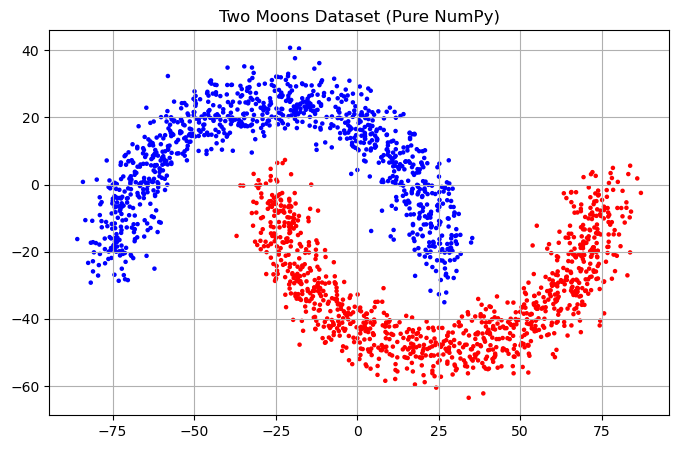

In [2]:
# dataset_moons_numpy.ipynb
# 03/Apr/2026

import numpy as np
import matplotlib.pyplot as plt

def generate_moons(n_samples, noise=0.05):
    """Generates two-moons dataset using only NumPy."""
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    # Moon 1: Upper semi-circle
    # Generate angles from 0 to Pi
    phi_out = np.linspace(0, np.pi, n_samples_out)
    outer_circ_x = np.cos(phi_out)
    outer_circ_y = np.sin(phi_out)

    # Moon 2: Lower semi-circle
    # Generate angles from 0 to Pi, then flip/shift
    phi_in = np.linspace(0, np.pi, n_samples_in)
    inner_circ_x = 1 - np.cos(phi_in)
    inner_circ_y = 1 - np.sin(phi_in) - 0.5

    # Combine
    x = np.append(outer_circ_x, inner_circ_x)
    y = np.append(outer_circ_y, inner_circ_y)
    points = np.column_stack([x, y])
    
    # Add labels (0 for first moon, 1 for second)
    labels = np.hstack([np.zeros(n_samples_out), np.ones(n_samples_in)])

    # Add Gaussian noise
    if noise:
        points += np.random.normal(scale=noise, size=points.shape)

    # Shuffle the data
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    return points[indices].astype(np.float32), labels[indices].astype(np.float32)

# --- Configuration ---
TOTAL_SAMPLES = 1_000_000
TRAIN_SIZE = 900_000
VAL_SIZE = 50_000
TEST_SIZE = 50_000

# Generate full data
all_points, all_labels = generate_moons(TOTAL_SAMPLES, noise=0.1)

# Scale to your range (-100 to 100)
# make_moons is naturally around -1 to 2, so we scale and center it
all_points = (all_points * 50) - 25

# Split data
train_points = all_points[:TRAIN_SIZE]
train_labels = all_labels[:TRAIN_SIZE]

val_points = all_points[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]
val_labels = all_labels[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]

test_points = all_points[TRAIN_SIZE + VAL_SIZE:]
test_labels = all_labels[TRAIN_SIZE + VAL_SIZE:]

# --- Visual Check ---
plt.figure(figsize=(8, 5))
plt.scatter(train_points[:2000, 0], train_points[:2000, 1], c=train_labels[:2000], cmap='bwr', s=5)
plt.title("Two Moons Dataset (Pure NumPy)")
plt.grid(True)
plt.show()

# Save to disk
np.savez_compressed("moons_dataset_numpy.npz", 
                    train_points=train_points, train_labels=train_labels,
                    validation_points=val_points, validation_labels=val_labels,
                    test_points=test_points, test_labels=test_labels)